In [1]:
#=================================
# Imports
#=================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

N_SAMPLES = 60000

print("Dataset size:", N_SAMPLES)

Dataset size: 60000


In [2]:
#=================================
# تولید اطلاعات Task و User
#=================================

n = N_SAMPLES

data = pd.DataFrame({
    "task_priority": np.random.randint(1, 6, n),

    "task_duration": np.random.choice(
        [30, 45, 60, 90, 120, 150, 180],
        n
    ),

    "deadline_hours": np.random.randint(
        4, 169, n
    ),

    "slot_start_hour": np.random.randint(
        6, 23, n
    ),

    "slot_duration": np.random.choice(
        [30, 45, 60, 90, 120, 150, 180],
        n
    ),

    "preferred_start_hour": np.random.randint(
        6, 23, n
    ),

    "day_of_week": np.random.randint(
        0, 7, n
    ),

    "is_weekend": np.random.randint(
        0, 2, n
    ),

    "repeated_task": np.random.choice(
        [0, 1],
        n,
        p=[0.75, 0.25]
    ),

    "reminder_exists": np.random.choice(
        [0, 1],
        n,
        p=[0.6, 0.4]
    ),

    "category": np.random.randint(
        0, 6,
        n
    )
})

print(data.shape)
data.head()

(60000, 11)


,task_priority,task_duration,deadline_hours,slot_start_hour,slot_duration,preferred_start_hour,day_of_week,is_weekend,repeated_task,reminder_exists,category
0,4,30,110,21,120,13,2,1,1,0,5
1,5,60,156,13,30,10,1,1,0,1,3
2,3,150,111,22,120,10,5,1,0,1,1
3,5,90,75,7,150,6,0,1,1,0,1
4,5,180,112,18,180,21,3,0,0,1,0


In [3]:
#=================================
# محاسبه Hard Constraints
#=================================

# Does the task fit inside the slot?
data["duration_fit"] = (
    data["task_duration"] <= data["slot_duration"]
).astype(int)

# Simulated user availability
data["user_available"] = np.random.choice(
    [0, 1],
    n,
    p=[0.20, 0.80]
)

# Does the task fit before the deadline?
slot_end_hour = (
    data["slot_start_hour"] +
    data["task_duration"] / 60
)

data["before_deadline"] = (
    slot_end_hour <= (
        6 + data["deadline_hours"] / 24
    )
).astype(int)

# Final validity
data["valid_slot"] = (
    (data["duration_fit"] == 1) &
    (data["user_available"] == 1) &
    (data["before_deadline"] == 1)
).astype(int)

print(
    "Valid slots:",
    data["valid_slot"].mean()
)

Valid slots: 0.07953333333333333


In [4]:
#=================================
# Time Preference
#=================================

time_difference = np.abs(
    data["slot_start_hour"] -
    data["preferred_start_hour"]
)

# Circular 24-hour distance
time_difference = np.minimum(
    time_difference,
    24 - time_difference
)

data["preferred_time_match"] = np.exp(
    -time_difference / 4
)

In [5]:
#=================================
# Priority و Deadline
#=================================

data["priority_score"] = (
    data["task_priority"] / 5.0
)

data["deadline_pressure"] = np.clip(
    1 -
    (data["deadline_hours"] / 168.0),
    0,
    1
)

In [6]:
#=================================
# Duration Efficiency
#=================================

data["duration_efficiency"] = np.clip(
    data["task_duration"] /
    data["slot_duration"],
    0,
    1
)

In [7]:
#=================================
# ساخت Suitability Score
#=================================

noise = np.random.normal(
    0,
    0.025,
    n
)

data["suitability_score"] = (
    0.35 * data["priority_score"]
    + 0.30 * data["deadline_pressure"]
    + 0.25 * data["preferred_time_match"]
    + 0.05 * data["duration_efficiency"]
    + 0.025 * data["repeated_task"]
    + 0.025 * data["reminder_exists"]
    + noise
)

data["suitability_score"] = np.clip(
    data["suitability_score"],
    0,
    1
)

# Invalid slots are not candidates for ML
data.loc[
    data["valid_slot"] == 0,
    "suitability_score"
] = 0

In [8]:
#=================================
# فقط Slot های معتبر برای آموزش
#=================================

valid_data = data[
    data["valid_slot"] == 1
].copy()

print(
    "Original samples:",
    len(data)
)

print(
    "Valid samples:",
    len(valid_data)
)

print(
    "Valid percentage:",
    len(valid_data) / len(data) * 100
)

Original samples: 60000
Valid samples: 4772
Valid percentage: 7.953333333333333


In [9]:
#=================================
# بررسی Dataset
#=================================

print(valid_data.isnull().sum())

print(
    "\nDuplicate rows:",
    valid_data.duplicated().sum()
)

print(
    "\nScore statistics:"
)

print(
    valid_data["suitability_score"].describe()
)

task_priority           0
task_duration           0
deadline_hours          0
slot_start_hour         0
slot_duration           0
preferred_start_hour    0
day_of_week             0
is_weekend              0
repeated_task           0
reminder_exists         0
category                0
duration_fit            0
user_available          0
before_deadline         0
valid_slot              0
preferred_time_match    0
priority_score          0
deadline_pressure       0
duration_efficiency     0
suitability_score       0
dtype: int64

Duplicate rows: 0

Score statistics:
count    4772.000000
mean        0.427723
std         0.139804
min         0.055846
25%         0.328281
50%         0.425727
75%         0.522613
max         0.921622
Name: suitability_score, dtype: float64


In [10]:
#=================================
# Feature های نهایی مدل
#=================================

feature_columns = [
    "task_priority",
    "task_duration",
    "deadline_hours",
    "slot_start_hour",
    "slot_duration",
    "preferred_start_hour",
    "preferred_time_match",
    "deadline_pressure",
    "duration_efficiency",
    "day_of_week",
    "is_weekend",
    "repeated_task",
    "reminder_exists",
    "category"
]

X = valid_data[feature_columns]

y = valid_data["suitability_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

X shape: (4772, 14)
y shape: (4772,)

Features:
- task_priority
- task_duration
- deadline_hours
- slot_start_hour
- slot_duration
- preferred_start_hour
- preferred_time_match
- deadline_pressure
- duration_efficiency
- day_of_week
- is_weekend
- repeated_task
- reminder_exists
- category


In [11]:
#=================================
# Train / Validation / Test
#=================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3340, 14)
Validation: (716, 14)
Test: (716, 14)


In [12]:
#=================================
# آموزش Random Forest
#=================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [13]:
#=================================
# Validation
#=================================

val_pred = rf_model.predict(X_val)

val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)

print("=== VALIDATION ===")
print("MAE :", val_mae)
print("RMSE:", val_rmse)
print("R2  :", val_r2)

=== VALIDATION ===
MAE : 0.025470835028075504
RMSE: 0.03225637548295061
R2  : 0.9429262172913466


In [14]:
#=================================
# Test نهایی
#=================================

test_pred = rf_model.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print("=== FINAL TEST RESULTS ===")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R2  :", test_r2)

=== FINAL TEST RESULTS ===
MAE : 0.024269048383284756
RMSE: 0.030653586970139257
R2  : 0.952271329810692


In [15]:
#=================================
# Feature Importance
#=================================

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(
    importance.to_string(index=False)
)

             Feature  Importance
       task_priority    0.514699
preferred_time_match    0.134938
      deadline_hours    0.109115
preferred_start_hour    0.105314
   deadline_pressure    0.104276
 duration_efficiency    0.009435
     reminder_exists    0.004356
       repeated_task    0.003605
       slot_duration    0.003020
         day_of_week    0.002881
            category    0.002665
       task_duration    0.002607
     slot_start_hour    0.002077
          is_weekend    0.001011


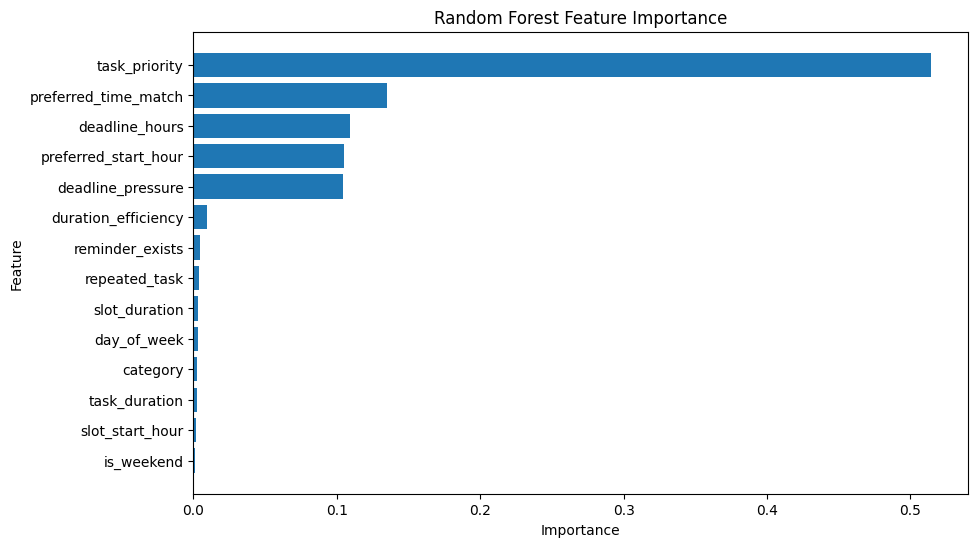

In [16]:
#=================================
# نمودار Feature Importance
#=================================

plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

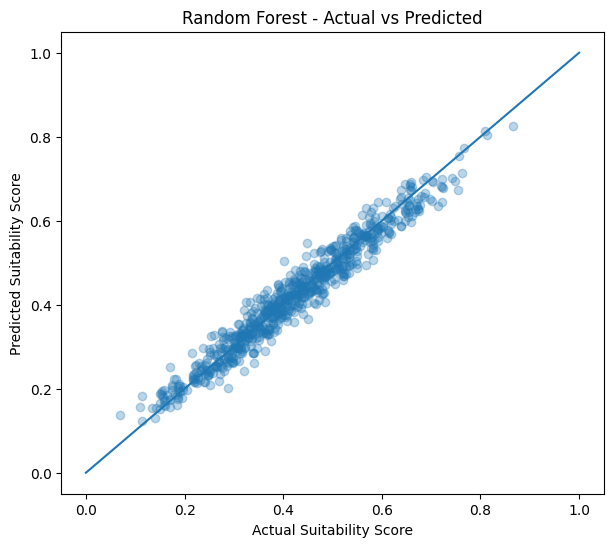

In [17]:
#=================================
# نمودار Actual vs Predicted
#=================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.3
)

plt.plot(
    [0, 1],
    [0, 1]
)

plt.xlabel("Actual Suitability Score")
plt.ylabel("Predicted Suitability Score")

plt.title(
    "Random Forest - Actual vs Predicted"
)

plt.show()

In [18]:
#=================================
# تست یک Task واقعی
#=================================

task = {
    "task_priority": 5,
    "task_duration": 120,
    "deadline_hours": 24,
    "preferred_start_hour": 19,
    "day_of_week": 2,
    "is_weekend": 0,
    "repeated_task": 0,
    "reminder_exists": 1,
    "category": 0
}

candidate_hours = [
    9,
    11,
    14,
    17,
    19,
    21
]

candidate_rows = []

for hour in candidate_hours:

    slot_duration = 120

    time_diff = abs(
        hour - task["preferred_start_hour"]
    )

    time_diff = min(
        time_diff,
        24 - time_diff
    )

    preferred_match = np.exp(
        -time_diff / 4
    )

    deadline_pressure = np.clip(
        1 -
        task["deadline_hours"] / 168,
        0,
        1
    )

    duration_efficiency = min(
        task["task_duration"] /
        slot_duration,
        1
    )

    row = {
        "task_priority": task["task_priority"],
        "task_duration": task["task_duration"],
        "deadline_hours": task["deadline_hours"],
        "slot_start_hour": hour,
        "slot_duration": slot_duration,
        "preferred_start_hour": task["preferred_start_hour"],
        "preferred_time_match": preferred_match,
        "deadline_pressure": deadline_pressure,
        "duration_efficiency": duration_efficiency,
        "day_of_week": task["day_of_week"],
        "is_weekend": task["is_weekend"],
        "repeated_task": task["repeated_task"],
        "reminder_exists": task["reminder_exists"],
        "category": task["category"]
    }

    candidate_rows.append(row)

candidate_df = pd.DataFrame(
    candidate_rows
)

candidate_df["predicted_score"] = rf_model.predict(
    candidate_df[feature_columns]
)

candidate_df[
    [
        "slot_start_hour",
        "predicted_score"
    ]
].sort_values(
    "predicted_score",
    ascending=False
)

,slot_start_hour,predicted_score
4,19,0.729735
3,17,0.702682
5,21,0.702682
2,14,0.688977
1,11,0.687643
0,9,0.686724


In [19]:
#=================================
# ذخیره مدل
#=================================

import joblib

joblib.dump(
    rf_model,
    "personal_planner_random_forest.pkl"
)

print(
    "Model saved successfully."
)

Model saved successfully.


In [20]:
#=================================
# ذخیره Feature Order
#=================================

import json

with open(
    "feature_columns.json",
    "w"
) as f:

    json.dump(
        feature_columns,
        f,
        indent=4
    )

print(
    "Feature configuration saved."
)

Feature configuration saved.


In [21]:
#=================================
# ذخیره Dataset نهایی
#=================================

valid_data.to_csv(
    "personal_planner_final_dataset.csv",
    index=False
)

print(
    "Final dataset saved."
)

Final dataset saved.


In [22]:
#=================================
# دانلود همه فایل‌ها
#=================================

from google.colab import files

files.download(
    "personal_planner_final_dataset.csv"
)

files.download(
    "personal_planner_random_forest.pkl"
)

files.download(
    "feature_columns.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# =================================
# تست مدل ذخیره شده
# =================================

import joblib
import json
import pandas as pd

# Load model
loaded_model = joblib.load(
    "personal_planner_random_forest.pkl"
)

# Load feature order
with open(
    "feature_columns.json",
    "r"
) as f:
    loaded_features = json.load(f)

print("Model loaded successfully.")
print("\nFeatures used by model:")

for feature in loaded_features:
    print("-", feature)

# Test prediction using existing test data
loaded_pred = loaded_model.predict(
    X_test[loaded_features]
)

loaded_mae = mean_absolute_error(
    y_test,
    loaded_pred
)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_pred
    )
)

loaded_r2 = r2_score(
    y_test,
    loaded_pred
)

print("\n=== LOADED MODEL TEST ===")
print("MAE :", loaded_mae)
print("RMSE:", loaded_rmse)
print("R2  :", loaded_r2)

Model loaded successfully.

Features used by model:
- task_priority
- task_duration
- deadline_hours
- slot_start_hour
- slot_duration
- preferred_start_hour
- preferred_time_match
- deadline_pressure
- duration_efficiency
- day_of_week
- is_weekend
- repeated_task
- reminder_exists
- category

=== LOADED MODEL TEST ===
MAE : 0.02426904838328476
RMSE: 0.030653586970139257
R2  : 0.952271329810692


In [24]:
# =================================
# Scheduling Algorithm , قسمت اصلی پروژه
# =================================

In [25]:
# ==========================================
# PERSONAL PLANNER SCHEDULING ALGORITHM
# ==========================================

import numpy as np
import pandas as pd


def calculate_preferred_time_match(
    slot_start_hour,
    preferred_start_hour
):
    diff = abs(
        slot_start_hour -
        preferred_start_hour
    )

    diff = min(
        diff,
        24 - diff
    )

    return np.exp(-diff / 4)


def calculate_deadline_pressure(
    deadline_hours
):
    return np.clip(
        1 - deadline_hours / 168,
        0,
        1
    )


def calculate_duration_efficiency(
    task_duration,
    slot_duration
):
    return np.clip(
        task_duration / slot_duration,
        0,
        1
    )


def create_candidate_slots(
    task,
    available_slots
):

    candidates = []

    for slot in available_slots:

        slot_start = slot["start_hour"]
        slot_duration = slot["duration"]

        # -------------------------
        # Hard Constraint 1
        # Duration
        # -------------------------

        if task["task_duration"] > slot_duration:
            continue

        # -------------------------
        # Hard Constraint 2
        # Availability
        # -------------------------

        if not slot["available"]:
            continue

        # -------------------------
        # Hard Constraint 3
        # Deadline
        # -------------------------

        slot_end_hour = (
            slot_start +
            task["task_duration"] / 60
        )

        deadline_end = (
            slot["current_hour"] +
            task["deadline_hours"] / 1
        )

        if slot_end_hour > deadline_end:
            continue

        # -------------------------
        # Feature Calculation
        # -------------------------

        preferred_match = calculate_preferred_time_match(
            slot_start,
            task["preferred_start_hour"]
        )

        deadline_pressure = calculate_deadline_pressure(
            task["deadline_hours"]
        )

        duration_efficiency = calculate_duration_efficiency(
            task["task_duration"],
            slot_duration
        )

        row = {
            "task_priority":
                task["task_priority"],

            "task_duration":
                task["task_duration"],

            "deadline_hours":
                task["deadline_hours"],

            "slot_start_hour":
                slot_start,

            "slot_duration":
                slot_duration,

            "preferred_start_hour":
                task["preferred_start_hour"],

            "preferred_time_match":
                preferred_match,

            "deadline_pressure":
                deadline_pressure,

            "duration_efficiency":
                duration_efficiency,

            "day_of_week":
                task["day_of_week"],

            "is_weekend":
                task["is_weekend"],

            "repeated_task":
                task["repeated_task"],

            "reminder_exists":
                task["reminder_exists"],

            "category":
                task["category"]
        }

        candidates.append(row)

    return pd.DataFrame(candidates)


def schedule_task(
    task,
    available_slots,
    model
):

    candidates = create_candidate_slots(
        task,
        available_slots
    )

    if candidates.empty:

        return None

    # -------------------------
    # Predict suitability
    # -------------------------

    candidates["predicted_score"] = model.predict(
        candidates[feature_columns]
    )

    # -------------------------
    # Select best slot
    # -------------------------

    candidates = candidates.sort_values(
        "predicted_score",
        ascending=False
    )

    best_slot = candidates.iloc[0]

    return best_slot, candidates

In [26]:
# ==========================================
# TEST SCHEDULING ALGORITHM
# ==========================================

test_task = {

    "task_priority": 5,

    "task_duration": 120,

    "deadline_hours": 24,

    "preferred_start_hour": 19,

    "day_of_week": 2,

    "is_weekend": 0,

    "repeated_task": 0,

    "reminder_exists": 1,

    "category": 0,

    "current_hour": 6
}


available_slots = [

    {
        "start_hour": 9,
        "duration": 120,
        "available": True,
        "current_hour": 6
    },

    {
        "start_hour": 11,
        "duration": 120,
        "available": True,
        "current_hour": 6
    },

    {
        "start_hour": 14,
        "duration": 120,
        "available": True,
        "current_hour": 6
    },

    {
        "start_hour": 17,
        "duration": 120,
        "available": True,
        "current_hour": 6
    },

    {
        "start_hour": 19,
        "duration": 120,
        "available": True,
        "current_hour": 6
    },

    {
        "start_hour": 21,
        "duration": 120,
        "available": True,
        "current_hour": 6
    }
]


result = schedule_task(
    test_task,
    available_slots,
    loaded_model
)


if result is not None:

    best_slot, all_candidates = result

    print("=== SCHEDULING RESULT ===")

    print(
        "\nBest Slot:"
    )

    print(
        "Start:",
        best_slot["slot_start_hour"]
    )

    print(
        "Duration:",
        best_slot["slot_duration"],
        "minutes"
    )

    print(
        "Predicted Score:",
        best_slot["predicted_score"]
    )

    print("\nAll Candidates:")

    print(
        all_candidates[
            [
                "slot_start_hour",
                "predicted_score"
            ]
        ].to_string(index=False)
    )

else:

    print(
        "No valid slot found."
    )

=== SCHEDULING RESULT ===

Best Slot:
Start: 19.0
Duration: 120.0 minutes
Predicted Score: 0.7297349794164607

All Candidates:
 slot_start_hour  predicted_score
              19         0.729735
              17         0.702682
              21         0.702682
              14         0.688977
              11         0.687643
               9         0.686724


In [27]:
# ==========================================
# MULTI-TASK PERSONAL PLANNER
# ==========================================

import pandas as pd
import numpy as np


def calculate_preferred_match(hour, preferred_hour):
    diff = abs(hour - preferred_hour)
    diff = min(diff, 24 - diff)

    return np.exp(-diff / 4)


def calculate_deadline_pressure(deadline_hours):
    return np.clip(
        1 - deadline_hours / 168,
        0,
        1
    )


def create_candidate(
    task,
    start_hour,
    slot_duration
):

    preferred_match = calculate_preferred_match(
        start_hour,
        task["preferred_start_hour"]
    )

    deadline_pressure = calculate_deadline_pressure(
        task["deadline_hours"]
    )

    duration_efficiency = np.clip(
        task["task_duration"] / slot_duration,
        0,
        1
    )

    return {
        "task_priority": task["task_priority"],
        "task_duration": task["task_duration"],
        "deadline_hours": task["deadline_hours"],
        "slot_start_hour": start_hour,
        "slot_duration": slot_duration,
        "preferred_start_hour": task["preferred_start_hour"],
        "preferred_time_match": preferred_match,
        "deadline_pressure": deadline_pressure,
        "duration_efficiency": duration_efficiency,
        "day_of_week": task["day_of_week"],
        "is_weekend": task["is_weekend"],
        "repeated_task": task["repeated_task"],
        "reminder_exists": task["reminder_exists"],
        "category": task["category"]
    }


def has_conflict(start, duration, scheduled_tasks):

    end = start + duration / 60

    for item in scheduled_tasks:

        existing_start = item["start_hour"]
        existing_end = (
            existing_start +
            item["duration"] / 60
        )

        # overlap
        if start < existing_end and end > existing_start:
            return True

    return False


def schedule_tasks(tasks, candidate_hours):

    scheduled = []

    # اولویت بالاتر اول
    tasks_sorted = sorted(
        tasks,
        key=lambda x: (
            x["task_priority"],
            -x["deadline_hours"]
        ),
        reverse=True
    )

    for task in tasks_sorted:

        candidates = []

        slot_duration = task["task_duration"]

        for hour in candidate_hours:

            # بررسی تداخل
            if has_conflict(
                hour,
                task["task_duration"],
                scheduled
            ):
                continue

            row = create_candidate(
                task,
                hour,
                slot_duration
            )

            candidates.append(row)

        if not candidates:
            print(
                f"WARNING: No available slot for: "
                f"{task['title']}"
            )
            continue

        candidate_df = pd.DataFrame(candidates)

        candidate_df["predicted_score"] = rf_model.predict(
            candidate_df[feature_columns]
        )

        # بهترین Slot
        best = candidate_df.sort_values(
            "predicted_score",
            ascending=False
        ).iloc[0]

        scheduled.append({
            "task_id": task["task_id"],
            "title": task["title"],
            "start_hour": float(
                best["slot_start_hour"]
            ),
            "duration": task["task_duration"],
            "score": float(
                best["predicted_score"]
            ),
            "priority": task["task_priority"]
        })

    return pd.DataFrame(scheduled)

In [28]:
# ==========================================
# TEST MULTI-TASK SCHEDULER
# ==========================================

tasks = [

    {
        "task_id": 1,
        "title": "Study Machine Learning",
        "task_priority": 5,
        "task_duration": 120,
        "deadline_hours": 24,
        "preferred_start_hour": 19,
        "day_of_week": 2,
        "is_weekend": 0,
        "repeated_task": 0,
        "reminder_exists": 1,
        "category": 0
    },

    {
        "task_id": 2,
        "title": "Exercise",
        "task_priority": 3,
        "task_duration": 60,
        "deadline_hours": 48,
        "preferred_start_hour": 17,
        "day_of_week": 2,
        "is_weekend": 0,
        "repeated_task": 1,
        "reminder_exists": 1,
        "category": 1
    },

    {
        "task_id": 3,
        "title": "Read Book",
        "task_priority": 2,
        "task_duration": 60,
        "deadline_hours": 72,
        "preferred_start_hour": 14,
        "day_of_week": 2,
        "is_weekend": 0,
        "repeated_task": 0,
        "reminder_exists": 0,
        "category": 2
    }
]


candidate_hours = [
    9,
    11,
    13,
    14,
    15,
    17,
    18,
    19,
    20,
    21
]


result = schedule_tasks(
    tasks,
    candidate_hours
)

print("\n=== FINAL SCHEDULE ===\n")

print(
    result.to_string(index=False)
)


=== FINAL SCHEDULE ===

 task_id                  title  start_hour  duration    score  priority
       1 Study Machine Learning        19.0       120 0.729735         5
       2               Exercise        17.0        60 0.613257         3
       3              Read Book        14.0        60 0.512533         2


In [29]:
# ==========================================
# یک تست مهم برای تداخل
# ==========================================

print("\n=== CONFLICT TEST ===")

if len(result) > 1:

    conflict_found = False

    for i in range(len(result)):

        for j in range(i + 1, len(result)):

            start1 = result.iloc[i]["start_hour"]
            end1 = (
                start1 +
                result.iloc[i]["duration"] / 60
            )

            start2 = result.iloc[j]["start_hour"]
            end2 = (
                start2 +
                result.iloc[j]["duration"] / 60
            )

            if start1 < end2 and start2 < end1:

                conflict_found = True

    if conflict_found:
        print("FAIL: Schedule contains conflicts")
    else:
        print("SUCCESS: No schedule conflicts")

else:
    print("Not enough tasks for conflict test")


=== CONFLICT TEST ===
SUCCESS: No schedule conflicts


In [30]:
# ==========================================
# نصب ONNX
# ==========================================

!pip install -q skl2onnx onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 25.3 MB/s eta 0:00:00


In [31]:
# ==========================================
# تبدیل مدل
# ==========================================

# ==========================================
# RANDOM FOREST -> ONNX
# ==========================================

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx

# مدل ما 14 feature دارد
initial_type = [
    (
        "float_input",
        FloatTensorType([None, len(feature_columns)])
    )
]

onnx_model = convert_sklearn(
    rf_model,
    initial_types=initial_type,
    target_opset=17
)

with open(
    "personal_planner_random_forest.onnx",
    "wb"
) as f:
    f.write(
        onnx_model.SerializeToString()
    )

print("ONNX model saved successfully.")

ONNX model saved successfully.


In [32]:
# ==========================================
# CHECK ONNX MODEL , بررسی صحت فایل ONNX
# ==========================================

import onnx

model = onnx.load(
    "personal_planner_random_forest.onnx"
)

onnx.checker.check_model(model)

print("ONNX model is valid.")

ONNX model is valid.


In [33]:
# ==========================================
# COMPARE SKLEARN vs ONNX , تست ONNX در برابر Random Forest
# ==========================================

import onnxruntime as ort
import numpy as np

session = ort.InferenceSession(
    "personal_planner_random_forest.onnx",
    providers=["CPUExecutionProvider"]
)

input_name = session.get_inputs()[0].name

# چند نمونه از Test
sample_X = X_test.iloc[:10]

# Random Forest
sklearn_predictions = rf_model.predict(
    sample_X
)

# ONNX
onnx_predictions = session.run(
    None,
    {
        input_name:
        sample_X.astype(np.float32).values
    }
)

print("Sklearn predictions:")
print(sklearn_predictions)

print("\nONNX output:")
print(onnx_predictions)

print(type(onnx_predictions))
print(onnx_predictions)

Sklearn predictions:
[0.22945494 0.63544397 0.64469032 0.18625519 0.20385726 0.33227168
 0.4585429  0.33727489 0.30196647 0.47025972]

ONNX output:
[array([[0.22945496],
       [0.6354441 ],
       [0.6446902 ],
       [0.18625514],
       [0.20385726],
       [0.3322716 ],
       [0.45854288],
       [0.33727497],
       [0.30196655],
       [0.47025958]], dtype=float32)]
<class 'list'>
[array([[0.22945496],
       [0.6354441 ],
       [0.6446902 ],
       [0.18625514],
       [0.20385726],
       [0.3322716 ],
       [0.45854288],
       [0.33727497],
       [0.30196655],
       [0.47025958]], dtype=float32)]


In [34]:
# ==========================================
# NUMERICAL COMPARISON , تست دقیق اختلاف
# ==========================================

onnx_output = onnx_predictions[0]

if isinstance(onnx_output, dict):
    onnx_output = np.array([
        item[1] for item in onnx_output
    ])

onnx_output = np.asarray(
    onnx_output,
    dtype=float
).reshape(-1)

sklearn_output = np.asarray(
    sklearn_predictions,
    dtype=float
).reshape(-1)

difference = np.abs(
    sklearn_output - onnx_output
)

print("Maximum difference:", difference.max())
print("Average difference:", difference.mean())

if np.allclose(
    sklearn_output,
    onnx_output,
    atol=1e-5
):
    print("SUCCESS: ONNX and Random Forest outputs match.")
else:
    print("WARNING: Outputs are different.")

Maximum difference: 1.3908132256990058e-07
Average difference: 7.070406797538009e-08
SUCCESS: ONNX and Random Forest outputs match.


In [36]:
from google.colab import files

files.download("personal_planner_random_forest.onnx")
files.download("feature_columns.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>